In [1]:
import pandas as pd
from datasets import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt
import time

# GPU check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

# Ensure reproducibility across runs
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080


In [2]:
df = pd.read_csv('../datasets/mail_phishing.csv')  
dataset = Dataset.from_pandas(df)

In [3]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)


Loading weights:   0%|                                                                                                  | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2020.69it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize(batch):
    return tokenizer(batch["text_combined"], padding="max_length", truncation=True)

start_time = time.time()
dataset = dataset.map(tokenize, batched=True)
end_time = time.time()

tokenize_duration = end_time - start_time

split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
test_dataset = split["test"]


Map:   0%|                                                                                                     | 0/82486 [00:00<?, ? examples/s]


Map:   1%|█                                                                                       | 1000/82486 [00:00<00:08, 9219.97 examples/s]


Map:   4%|███▏                                                                                   | 3000/82486 [00:00<00:06, 13034.37 examples/s]


Map:   6%|█████▎                                                                                 | 5000/82486 [00:00<00:05, 13072.77 examples/s]


Map:   8%|███████▍                                                                               | 7000/82486 [00:00<00:05, 12796.05 examples/s]

...


Map:  96%|███████████████████████████████████████████████████████████████████████████████████▎   | 79000/82486 [00:09<00:00, 4395.92 examples/s]


Map:  97%|████████████████████████████████████████████████████████████████████████████████████▍  | 80000/82486 [00:09<00:00, 5069.74 examples/s]


Map:  98%|██████████████████████████████████████████████████████████████████████████████████████▍ | 81000/82486 [00:16<00:02, 499.22 examples/s]


Map:  99%|███████████████████████████████████████████████████████████████████████████████████████▍| 82000/82486 [00:16<00:00, 640.41 examples/s]


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████| 82486/82486 [00:16<00:00, 4957.93 examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
training_args = TrainingArguments(
    output_dir=".checkpoints/bert-mail-finetuned",
    per_device_train_batch_size=16,
    num_train_epochs=3,
    fp16=False,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
trainer.train()
end_time = time.time()

training_duration = end_time - start_time

Step,Training Loss
500,0.164032
1000,0.090398
1500,0.060178
2000,0.056759
2500,0.042551
3000,0.051247
3500,0.038729
4000,0.030781
4500,0.017597
5000,0.011147



Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.30s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.30s/it]


Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]

...


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.25s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.25s/it]


Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.26s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.26s/it]

In [7]:
# evaluate() without prior train() requires this
trainer.remove_callback(NotebookProgressCallback)
metrics = trainer.evaluate()
print("\nmetrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print(f"tokenize_runtime: {tokenize_duration:.2f}s ({tokenize_duration/60:.2f}min)")
print(f"train_runtime: {training_duration:.2f}s ({training_duration/60:.2f}min)")


metrics:
eval_loss: 0.0292
eval_accuracy: 0.9952
eval_f1: 0.9954
eval_precision: 0.9955
eval_recall: 0.9953
eval_runtime: 47.8841
eval_samples_per_second: 344.5400
eval_steps_per_second: 43.0830
epoch: 3.0000
tokenize_runtime: 16.68s (0.28min)
train_runtime: 1920.11s (32.00min)


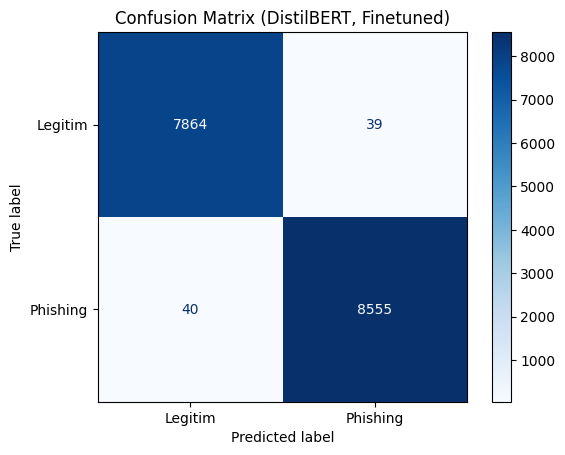

In [8]:
# confusion matrix
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitim", "Phishing"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (DistilBERT, Finetuned)")
plt.show()

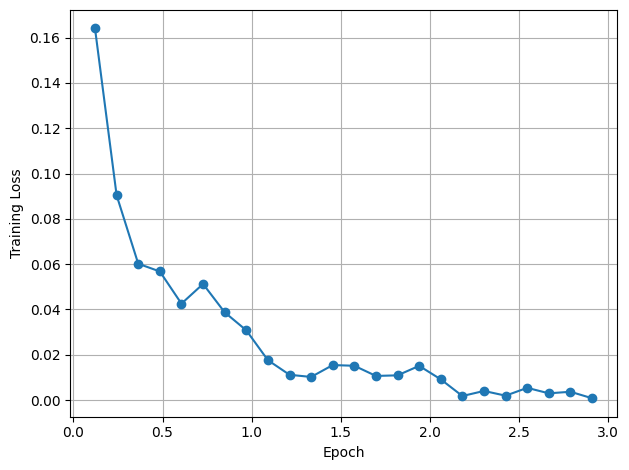

In [9]:
# loss curve
logs = trainer.state.log_history
epoch_logs = [log for log in logs if "loss" in log and "epoch" in log]
df = pd.DataFrame(epoch_logs)

plt.plot(df["epoch"], df["loss"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()